In [1]:
%load_ext autoreload
%autoreload 2

In [18]:
from dataclasses import dataclass
import numpy as np
from typing import Any, List, Callable
from collections import defaultdict
from mdp import Policy, MDP, Step, value_evaluation, Rollout, FlackyTramMDP
from functools import partial

class RLAlgorithm:
    def get_action(self, state: Any) -> Any:
        raise NotImplementedError
    def incorporate_feedback(self, state: Any, action: Any, reward: float, next_state: Any, is_end: bool):
        raise NotImplementedError

class StaticAgent(RLAlgorithm):
    def __init__(self, policy: Policy):
        self.policy = policy

    def get_action(self, state: Any) -> Any:
        return self.policy(state)

    def incorporate_feedback(self, state: Any, action: Any, reward: float, next_state: Any, is_end: bool):
        pass

In [19]:
def sample_transition(mdp: MDP, state: Any, action: Any) -> Step:
    steps = [successor for successor in mdp.successors(state) if successor.action == action]
    probs = [step.prob for step in steps]
    choice = np.random.choice(len(steps), p=probs)
    return steps[choice]

# Simulate multiple rollouts with an agent and MDP
# Policy: provided by agent
# Rollout environment: provided by MDP
# Return: utility of each rollout
def simulate(mdp: MDP, rl: RLAlgorithm, num_trials: int = 20) -> List[float]:
    utilities = []
    for _ in range(num_trials):
        state = mdp.start_state()
        steps = []
        while not mdp.is_end(state):
            action = rl.get_action(state)
            step = sample_transition(mdp, state, action)
             # !!end state should be next state in stead of state
            rl.incorporate_feedback(state, action, step.reward, step.state, mdp.is_end(step.state))
            steps.append(step)
            state = step.state
        rollout = Rollout(steps, mdp.discount())
        utilities.append(rollout.utility)
    return utilities

# Test simulation with static agent
np.random.seed(42)
tram_mdp = FlackyTramMDP(num_locs=10, failure_prob=0.4)
tram_policy = lambda s: "tram" if s * 2 <= tram_mdp.num_locs else "walk"
walk_policy = lambda s: "walk"
walk_agent = StaticAgent(walk_policy)
tram_agent = StaticAgent(tram_policy)
walk_utilities = simulate(tram_mdp, walk_agent, num_trials=1)
tram_utilities = simulate(tram_mdp, tram_agent, num_trials=30)
print("discount:", tram_mdp.discount())
print("walk utilities: ", walk_utilities)
print("tram utilities: ", tram_utilities)

discount: 0.9
walk utilities:  [-6.12579511]
tram utilities:  [-10.3809179, -6.8051, -6.8051, -6.8051, -10.3809179, -6.8051, -8.124590000000001, -11.34282611, -8.124590000000001, -10.3809179, -10.3809179, -6.8051, -11.34282611, -6.8051, -9.312131, -6.8051, -13.688920234190002, -9.312131, -8.124590000000001, -9.312131, -8.124590000000001, -6.8051, -12.208543499000001, -6.8051, -6.8051, -9.312131, -10.3809179, -14.320028210771001, -9.312131, -10.3809179]


In [20]:
#================== Model-Based Value Iteration ====================

class EstimateMDP(MDP):
    def __init__(self, discount: float):
        self.discount_ = discount
        # only one start state
        self.start_state_ = None
        # map from (state, action, next_state) to reward
        self.rewards = defaultdict(float)
        # map from (state, action, next_state) to count
        # { state: {
        #       action: {
        #          next_state: count
        #       }
        # }}
        self.transitions = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
        # support multiple end states
        self.end_states = set()

    def start_state(self) -> Any:
        return self.start_state_
        
    def successors(self, state: Any) -> List[Step]:
        steps = []
        for action, states in self.transitions[state].items():
            total_count = sum(states.values())
            for next_state, count in states.items():
                prob = count / total_count
                reward = self.rewards[(state, action, next_state)]
                steps.append(Step(action, reward, prob, next_state))
        return steps
    
    def is_end(self, state: Any) -> bool:
        return state in self.end_states
    
    def discount(self) -> float:
        return self.discount_

    def incorporate_feedback(self, state: Any, action: Any, reward: float, next_state: Any, is_end: bool):
        if self.start_state_ is None:
            self.start_state_ = state
        if is_end:
            # !!end state should be next state in stead of state
            self.end_states.add(next_state)
        self.rewards[(state, action, next_state)] = reward
        self.transitions[state][action][next_state] += 1

class ModelBasedValueIterationAgent(RLAlgorithm):
    def __init__(self, exploration_policy: Policy, discount: float = 1.0):
        # use exploration policy before estimated MDP is generated
        self.exploration_policy = exploration_policy
        # use estimated MDP as exploitation policy if exists
        self.exploitation_plicy = None
        self.mdp = EstimateMDP(discount)

    def get_action(self, state: Any) -> Any:
        if self.exploitation_plicy is None:
            return self.exploration_policy(state)
        else:
            # use exploration_policy as fallback policy if current state doesn't exist in MDP
            return self.exploitation_plicy.get(state, self.exploration_policy(state))
    
    def incorporate_feedback(self, state: Any, action: Any, reward: float, next_state: Any, is_end: bool):
        self.mdp.incorporate_feedback(state, action, reward, next_state, is_end)

    # Run value iteration to compute the optimal policy for the estimated MDP
    # use MDP as exploitation policy only after this call, usually after a couple of rollouts with exploration policy
    def run_value_iteration(self):
        self.exploitation_plicy = value_evaluation(self.mdp).pi

def walk_tram_exploration_policy(num_locs: int, state: Any) -> Any:
    if state * 2 <= num_locs:
        return np.random.choice(["walk", "tram"])
    else:
        return "walk"

# Test model based value iteration
exploration_policy = partial(walk_tram_exploration_policy, tram_mdp.num_locs)
agent = ModelBasedValueIterationAgent(exploration_policy, tram_mdp.discount())
exploration_utilities = simulate(tram_mdp, agent, 30)
print(np.mean(exploration_utilities))
agent.run_value_iteration()
mb_value_iteration_scores = simulate(tram_mdp, agent, 30)
print("optimal policy:", agent.exploitation_plicy)
print(np.mean(mb_value_iteration_scores))


-7.465425436493132
optimal policy: {1: np.str_('walk'), 2: np.str_('walk'), 3: np.str_('walk'), 4: np.str_('walk'), 5: np.str_('tram'), 6: 'walk', 7: 'walk', 8: 'walk', 9: 'walk', 10: None}
-5.31492112


In [21]:
#================== Model-Free Monte Carlo ==========================
# Run multiple rollouts and compute Q-value at end of each rollout 

class ModelFreeMonteCarlo(RLAlgorithm):
    def __init__(self, exploration_policy: Policy, epsilon: float = 0.4, discount: float = 1.0):
         self.exploration_policy = exploration_policy
         self.discount = discount
         self.epsilon = epsilon
         # map (state, action) to count. { state: { action: count }}
         self.counts = defaultdict(lambda: defaultdict(int))
         # map (state, action) to total Q-values (utilities)
         # { state: { action: utility }}
         self.sum_utilities =  defaultdict(lambda: defaultdict(float))
         # store steps in current rollout, used to compute Q-value at the end of each rollout
         self.rollout = []
         self.start_state = None

    def get_action(self, state: Any) -> Any:
        # if no action is found for the state, or in probability epsilon, use exploration policy
        if len(self.counts[state]) == 0 or np.random.random() < self.epsilon:
            return self.exploration_policy(state)
        else:
            # return action with current highest Q-value
            return self.pi(state)

    def pi(self, state: Any) -> Any:
        actions = list(self.counts[state].keys())
        if not actions: return self.exploration_policy(state)
        utilities = [self.Q(state, action) for action in actions]
        return actions[np.argmax(utilities)]
    
    def Q(self, state: Any, action: Any) -> float:
        total_utility = self.sum_utilities[state][action]
        count = self.counts[state][action]
        return total_utility / count

    def incorporate_feedback(self, state: Any, action: Any, reward: float, next_state: Any, is_end: bool):
        if self.start_state is None:
            self.start_state = state
        self.rollout.append(Step(action, reward, 1.0, next_state))

        if is_end:
            # Q[i] = reward + Q[i + 1] * discount, Q[end] = 0
            utilities = [0] * (len(self.rollout) + 1)
            for i in reversed(range(len(self.rollout))):
                step = self.rollout[i]
                # state is the next state in the previous step, or start state if no previous step
                state = self.start_state if i == 0 else self.rollout[i - 1].state
                utilities[i] = step.reward + utilities[i + 1] * self.discount
                self.sum_utilities[state][step.action] += utilities[i]
                self.counts[state][step.action] += 1
            self.rollout = []
            self.start_state = None

# Test model free monte carlo
rl = ModelFreeMonteCarlo(exploration_policy, epsilon=0.2, discount=0.9)
mf_mc_scores = simulate(tram_mdp, rl, 60)
print(mf_mc_scores)


[-7.027031, -7.027031, -7.027031, -6.4145900000000005, -7.12579511, -7.670917900000001, -9.49189511, -9.298805599000001, -10.614704635190002, -7.12579511, -6.12579511, -6.12579511, -7.242215599000001, -6.12579511, -6.12579511, -7.169315599000001, -6.12579511, -6.12579511, -6.12579511, -7.242215599000001, -6.12579511, -5.4145900000000005, -6.12579511, -7.169315599000001, -6.12579511, -6.12579511, -7.323215599000001, -6.12579511, -5.4145900000000005, -8.323215599000001, -7.12579511, -6.12579511, -6.12579511, -6.12579511, -5.7512, -6.12579511, -6.12579511, -6.12579511, -6.027031, -6.12579511, -6.12579511, -6.12579511, -6.12579511, -8.835795110000001, -6.5953279, -6.5953279, -6.12579511, -6.12579511, -6.12579511, -4.7512, -7.148962000000001, -5.932180000000001, -4.7512, -7.242215599000001, -8.2955558, -7.169315599000001, -10.44159022, -6.12579511, -8.413215599, -7.413215599000001]


In [22]:
class SARSA(RLAlgorithm):
    def __init__(self, exploration_policy: Policy, epsilon: float = 0.4, lr: float = 0.1, discount: float = 1.0):
        self.lr = lr
        self.exploration_policy = exploration_policy
        self.epsilon = epsilon
        self.discount = discount
        # Q table - map from (state, action) to Q value
        self.Q = defaultdict(lambda: defaultdict(float))

    def get_action(self, state: Any) -> Any:
        if len(self.Q[state]) == 0 or np.random.random() < self.epsilon:
            return self.exploration_policy(state)
        else:
            return self.pi(state)

    def pi(self, state: Any) -> Any:
        actions = list(self.Q[state].keys())
        if not actions: return None
        q_values = [self.Q[state][a] for a in actions]
        return actions[np.argmax(q_values)]

    def incorporate_feedback(self, state: Any, action: Any, reward: float, next_state: Any, is_end: bool):
        if is_end:
            utility = reward
        else:
            # On-Policy: use get_action to get next action to compute Q-value
            next_action = self.get_action(next_state)
            utility = reward + self.Q[next_state][next_action] * self.discount
        # Use gradient decend to graduatually update Q-value to target value
        self.Q[state][action] += self.lr * (utility - self.Q[state][action])

# Test SARSA
rl = SARSA(exploration_policy, epsilon=0.2, lr=0.1, discount=0.9)
sarsa_scores = simulate(tram_mdp, rl, num_trials=60)
print(sarsa_scores)
print(np.mean(sarsa_scores))

[-5.8051, -6.4612, -4.7512, -6.683131, -6.086080000000001, -5.0680000000000005, -6.00508, -7.377472000000001, -5.4145900000000005, -5.4145900000000005, -6.027031, -6.027031, -5.932180000000001, -6.3802, -5.4145900000000005, -6.027031, -10.614704635190002, -7.683131, -9.5718940391, -6.027031, -7.413215599000001, -8.169315599, -7.2343279, -8.413215599, -8.3523840391, -6.12579511, -7.12579511, -6.5953279, -5.4145900000000005, -7.323215599000001, -7.12459, -4.7512, -8.761894039100001, -7.323215599000001, -7.5953279, -6.12579511, -6.00508, -6.5953279, -6.027031, -4.7512, -9.181384039100001, -7.5953279, -4.7512, -6.027031, -6.873131000000001, -8.3523840391, -6.027031, -4.7512, -7.83579511, -4.7512, -7.169315599000001, -7.027031, -6.773131, -4.7512, -6.027031, -7.027031, -8.3523840391, -6.027031, -5.4145900000000005, -5.4145900000000005]
-6.602135490063166


In [23]:
class QLearning(SARSA):
    def incorporate_feedback(self, state: Any, action: Any, reward: float, next_state: Any, is_end: bool):
        if is_end:
            utility = reward
        else:
            # Off-Policy: use Q table to get next action to compute Q-value
            next_action = self.pi(next_state)
            # next_action could be empty in Q table, so use default value 0
            utility = reward + self.Q[next_state].get(next_action, 0.0) * self.discount
            # Use gradient decend to graduatually update Q-value to target value
            self.Q[state][action] += self.lr * (utility - self.Q[state][action])

# Test Q-learning
rl = QLearning(exploration_policy, epsilon=0.2, lr=0.1, discount=0.9)
ql_scores = simulate(tram_mdp, rl, num_trials=60)
print(ql_scores)
print(np.mean(ql_scores))

[-8.412131, -5.8051, -8.502131, -8.312131, -9.312131, -7.12459, -5.8051, -7.12459, -6.8051, -7.12459, -6.8051, -5.8051, -8.312131, -7.424327900000001, -7.027031, -8.51089511, -8.63282611, -5.4145900000000005, -5.4145900000000005, -10.046165171671001, -9.460804635190001, -6.12579511, -6.12579511, -6.12579511, -6.12579511, -6.12579511, -7.12579511, -6.12579511, -7.323215599000001, -6.12579511, -6.12579511, -7.12579511, -10.232294635190001, -6.12579511, -6.12579511, -6.12579511, -6.027031, -6.12579511, -7.3243279, -7.5132155990000005, -6.12579511, -8.413215599, -7.027031, -6.12579511, -6.027031, -6.12579511, -6.12579511, -6.12579511, -6.12579511, -7.12579511, -8.323215599000001, -6.027031, -5.7512, -6.12579511, -6.5953279, -7.3243279, -6.12579511, -6.12579511, -7.027031, -6.5953279]
-6.912184353300851


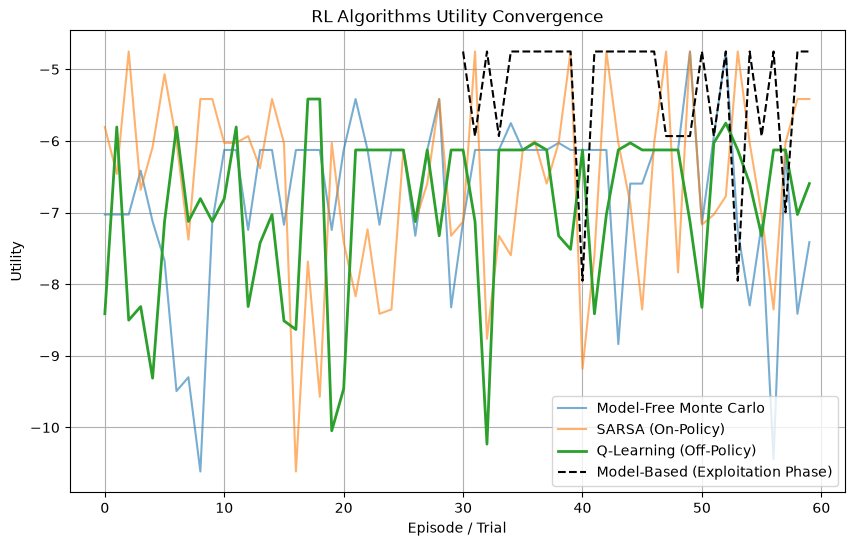

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(mf_mc_scores, label="Model-Free Monte Carlo", alpha=0.6)
plt.plot(sarsa_scores, label="SARSA (On-Policy)", alpha=0.6)
plt.plot(ql_scores, label="Q-Learning (Off-Policy)", linewidth=2)
plt.plot(range(30, 60), mb_value_iteration_scores, label="Model-Based (Exploitation Phase)", color='black', linestyle='--')
plt.title("RL Algorithms Utility Convergence")
plt.xlabel("Episode / Trial")
plt.ylabel("Utility")
plt.legend()
plt.grid(True)
plt.show()